# Lecture 10b: Large-scale multicountry models

This is the second of two notebooks for the lecture 10 slide deck. It replicates the core multicountry calculation from Section 5 of *Determinacy and Large-Scale Models in the Sequence Space*. We use the paper's simple no-beta-heterogeneity household block, combine its sequence-space Jacobians with the calibrated trade matrix, and solve for the responses to a deficit-financed US tax cut.

In [ ]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import sequence_jacobian as sj

from calibration import make_grids
from multicountry import solve

In [2]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=15)
plt.rc('text.latex', preamble=r'\usepackage{mathpazo}')

## Household block and calibration

The paper uses a simple household block for the Section 5 multicountry exercise rather than the beta-heterogeneity calibration used elsewhere in the workshop. The calibration chooses the single discount factor so that the impact MPC out of aggregate income is 0.2.

In [3]:
a_grid, e_grid, Pi_e = make_grids()
calib_hh = dict(r=0.02/4, Y=1, T=0, eis=1, a_grid=a_grid, e_grid=e_grid, Pi=Pi_e)

def income(Y, T, e_grid):
    y = (Y - T) * e_grid
    return y

hh = sj.hetblocks.hh_sim.hh.add_hetinputs([income])

In [4]:
mpc_target = 0.2

def mpc_error(beta):
    ss = hh.steady_state({**calib_hh, 'beta': beta})
    return hh.impulse_linear(ss, inputs={'Y': np.array([1, 0])}, outputs=['C'])['C'][0] - mpc_target

beta = optimize.brentq(mpc_error, 0.95, 0.99, xtol=1e-9)
ss = hh.steady_state({**calib_hh, 'beta': beta})
mpc = hh.impulse_linear(ss, inputs={'Y': np.array([1, 0])}, outputs=['C'])['C'][0]

print(f"beta = {ss['beta']:.9f}")
print(f"quarterly r = {ss['r']:.4f}")
print(f"annual assets / GDP = {ss['A'] / 4:.3f}")
print(f"impact MPC = {mpc:.3f}")

assert np.isclose(mpc, mpc_target)

beta = 0.973401589
quarterly r = 0.0050
annual assets / GDP = 0.680
impact MPC = 0.200


Compute the consumption and asset Jacobians with respect to aggregate income. We keep the paper's Section 5 truncation horizon exactly, `T = 1000` quarters.

In [5]:
T = 1000
J = hh.jacobian(ss, inputs=['Y'], outputs=['C', 'A'], T=T)
M, A = J['C', 'Y'], J['A', 'Y']

## Trade matrix

Load the calibrated country-by-country spending share matrix $\Pi$. The steady-state GDP shares are the unit eigenvector of $\Pi'$.

In [6]:
Pi = np.loadtxt('inputs/multicountry/Pi1.csv', delimiter=',')
Pi /= Pi.sum(axis=1)[:, np.newaxis]

countries = np.loadtxt('inputs/multicountry/countries1.csv', delimiter=',', dtype=str, skiprows=1, usecols=1)
N = len(Pi)
i_us = np.flatnonzero(countries == 'USA')[0]

assert len(countries) == N
assert np.max(np.abs(Pi.sum(axis=1) - 1)) < 1e-12
print(f"N = {N} countries, USA index = {i_us}")

N = 190 countries, USA index = 182


In [7]:
w, v = np.linalg.eig(Pi.T)
i = np.argmax(np.abs(w - 1) < 1e-2)
print(f"eigenvalue = {w[i].real:.12f}")
print(f"eigenvector residual = {np.max(np.abs(Pi.T @ v[:, i] - v[:, i])):.2e}")

y = v[:, i].real.copy()
y /= np.max(y)
assert y[i_us] > 0

eigenvalue = 1.000000000000
eigenvector residual = 8.30e-16


## US fiscal shock

The shock is the deficit-financed US tax cut used in Section 5 of the paper. Taxes fall on impact, debt rises, and later taxes service the debt.

In [8]:
dB0 = y[i_us] * np.arange(T+1)[1:] * 0.9**np.arange(T)
dT0 = -dB0.copy()
dT0[1:] += (1 + ss['r']) * dB0[:-1]

dG, dT, dB = (np.zeros((T, N)) for _ in range(3))
dT[:, i_us] = dT0
dB[:, i_us] = dB0

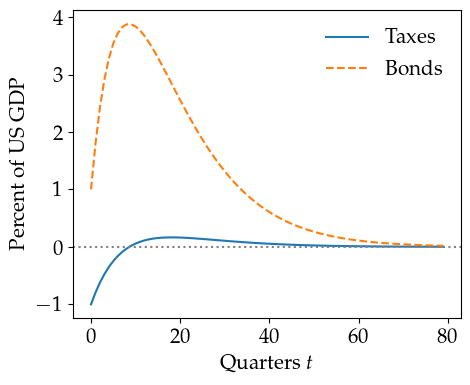

In [9]:
plt.figure(figsize =(5, 4))
plt.plot(dT0[:80]/y[i_us], label='Taxes')
plt.plot(dB0[:80]/y[i_us], label='Bonds', linestyle='--')
plt.legend(framealpha=0)
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.ylabel('Percent of US GDP')
plt.xlabel(r'Quarters $t$')
plt.savefig('figures/lecture10b_tax_bonds.pdf', transparent=True, bbox_inches='tight')

## Multicountry solve

The unknowns are output paths for all countries. The solver uses the Toeplitz structure of the sequence-space Jacobians to precondition the large linear system.

In [10]:
t0 = time.perf_counter()
dY = solve(M, A, Pi, dG, dT, dB, tol=1e-10)
solve_seconds = time.perf_counter() - t0

print(f"Multicountry solve time: {solve_seconds:.2f} seconds")
assert dY.shape == (T, N)

Iteration 1
0.019712231266526412
Iteration 2
0.0004372721970218944
Iteration 3
2.0031541185761886e-05
Iteration 4
1.1095516694186675e-06
Iteration 5
1.341714875356672e-07
Iteration 6
2.70693927664504e-08
Iteration 7
5.9081871176424315e-09
Iteration 8
1.9419094244651303e-09
Iteration 9
4.320770060517096e-10
Iteration 10
1.2013691257157597e-10
Iteration 11
1.492240809506688e-11
Iteration 12
4.3027177129481885e-12
Max error in solution is 1.487e-12
Multicountry solve time: 2.90 seconds


In [11]:
partialY = dG - M @ dT @ Pi
dY_alt = M @ dY @ Pi + partialY
err = np.max(np.abs(dY_alt - dY))

print(f"Residual check = {err:.2e}")
assert err < 1e-8

Residual check = 1.49e-12


## Responses

Scale each country's response by its own steady-state GDP share. The figure reproduces the key partner-response calculation from the paper without the appendix maps.

In [12]:
dY_scaled = dY / y
impact = dY_scaled[0, :]
later = dY_scaled[20, :]

to_plot = ['USA', 'MEX', 'CAN', 'CHN']
country_index = {c: np.flatnonzero(countries == c)[0] for c in to_plot}

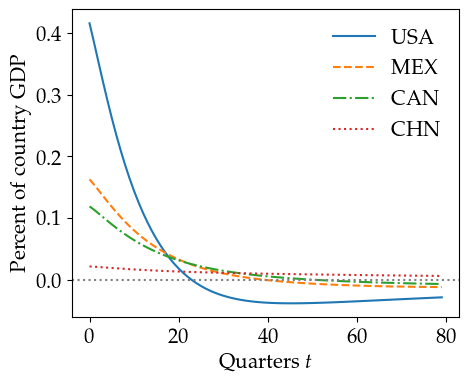

In [13]:
linst = ['-', '--', '-.', ':']

plt.figure(figsize =(5, 4))
for c, linestyle in zip(to_plot, linst):
    plt.plot(dY_scaled[:80, country_index[c]], label=c, linestyle=linestyle)

plt.legend(framealpha=0)
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.xlabel(r'Quarters $t$')
plt.ylabel('Percent of country GDP')
plt.savefig('figures/lecture10b_country_responses.pdf', transparent=True, bbox_inches='tight')